In [12]:
import pandas as pd

# Load the dataset
df = pd.read_csv("diet_recommendations.csv")

# Display the first few rows
print(df.head())


  Patient_ID  Age  Gender  Weight_kg  Height_cm   BMI  Disease_Type  Severity  \
0      P0001   56    Male       58.4        160  22.8       Obesity  Moderate   
1      P0002   69    Male      101.2        169  35.4      Diabetes      Mild   
2      P0003   46  Female       63.5        173  21.2  Hypertension      Mild   
3      P0004   32    Male       58.1        164  21.6           NaN      Mild   
4      P0005   60    Male       79.5        197  20.5      Diabetes  Moderate   

  Physical_Activity_Level  Daily_Caloric_Intake  Cholesterol_mg/dL  \
0                Moderate                  3079              173.3   
1                Moderate                  3032              199.2   
2               Sedentary                  1737              181.0   
3                Moderate                  2657              168.2   
4               Sedentary                  3496              200.4   

   Blood_Pressure_mmHg  Glucose_mg/dL Dietary_Restrictions Allergies  \
0                  1

In [14]:
# Show dataset information
print(df.info())

# Show summary statistics
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        1000 non-null   object 
 1   Age                               1000 non-null   int64  
 2   Gender                            1000 non-null   object 
 3   Weight_kg                         1000 non-null   float64
 4   Height_cm                         1000 non-null   int64  
 5   BMI                               1000 non-null   float64
 6   Disease_Type                      796 non-null    object 
 7   Severity                          1000 non-null   object 
 8   Physical_Activity_Level           1000 non-null   object 
 9   Daily_Caloric_Intake              1000 non-null   int64  
 10  Cholesterol_mg/dL                 1000 non-null   float64
 11  Blood_Pressure_mmHg               1000 non-null   int64  
 12  Glucose

In [15]:
print(df.isnull().sum())

Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64


In [16]:
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)

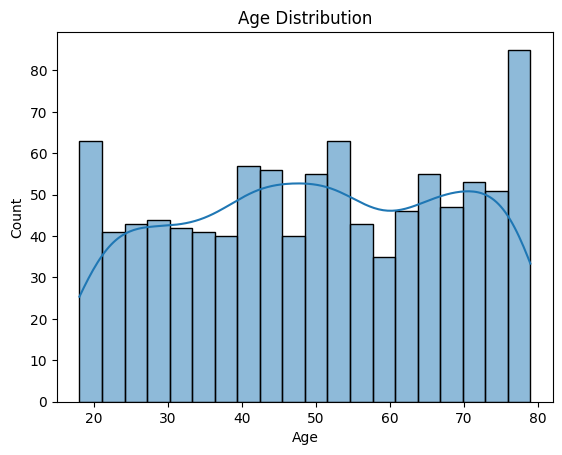

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot Age distribution
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

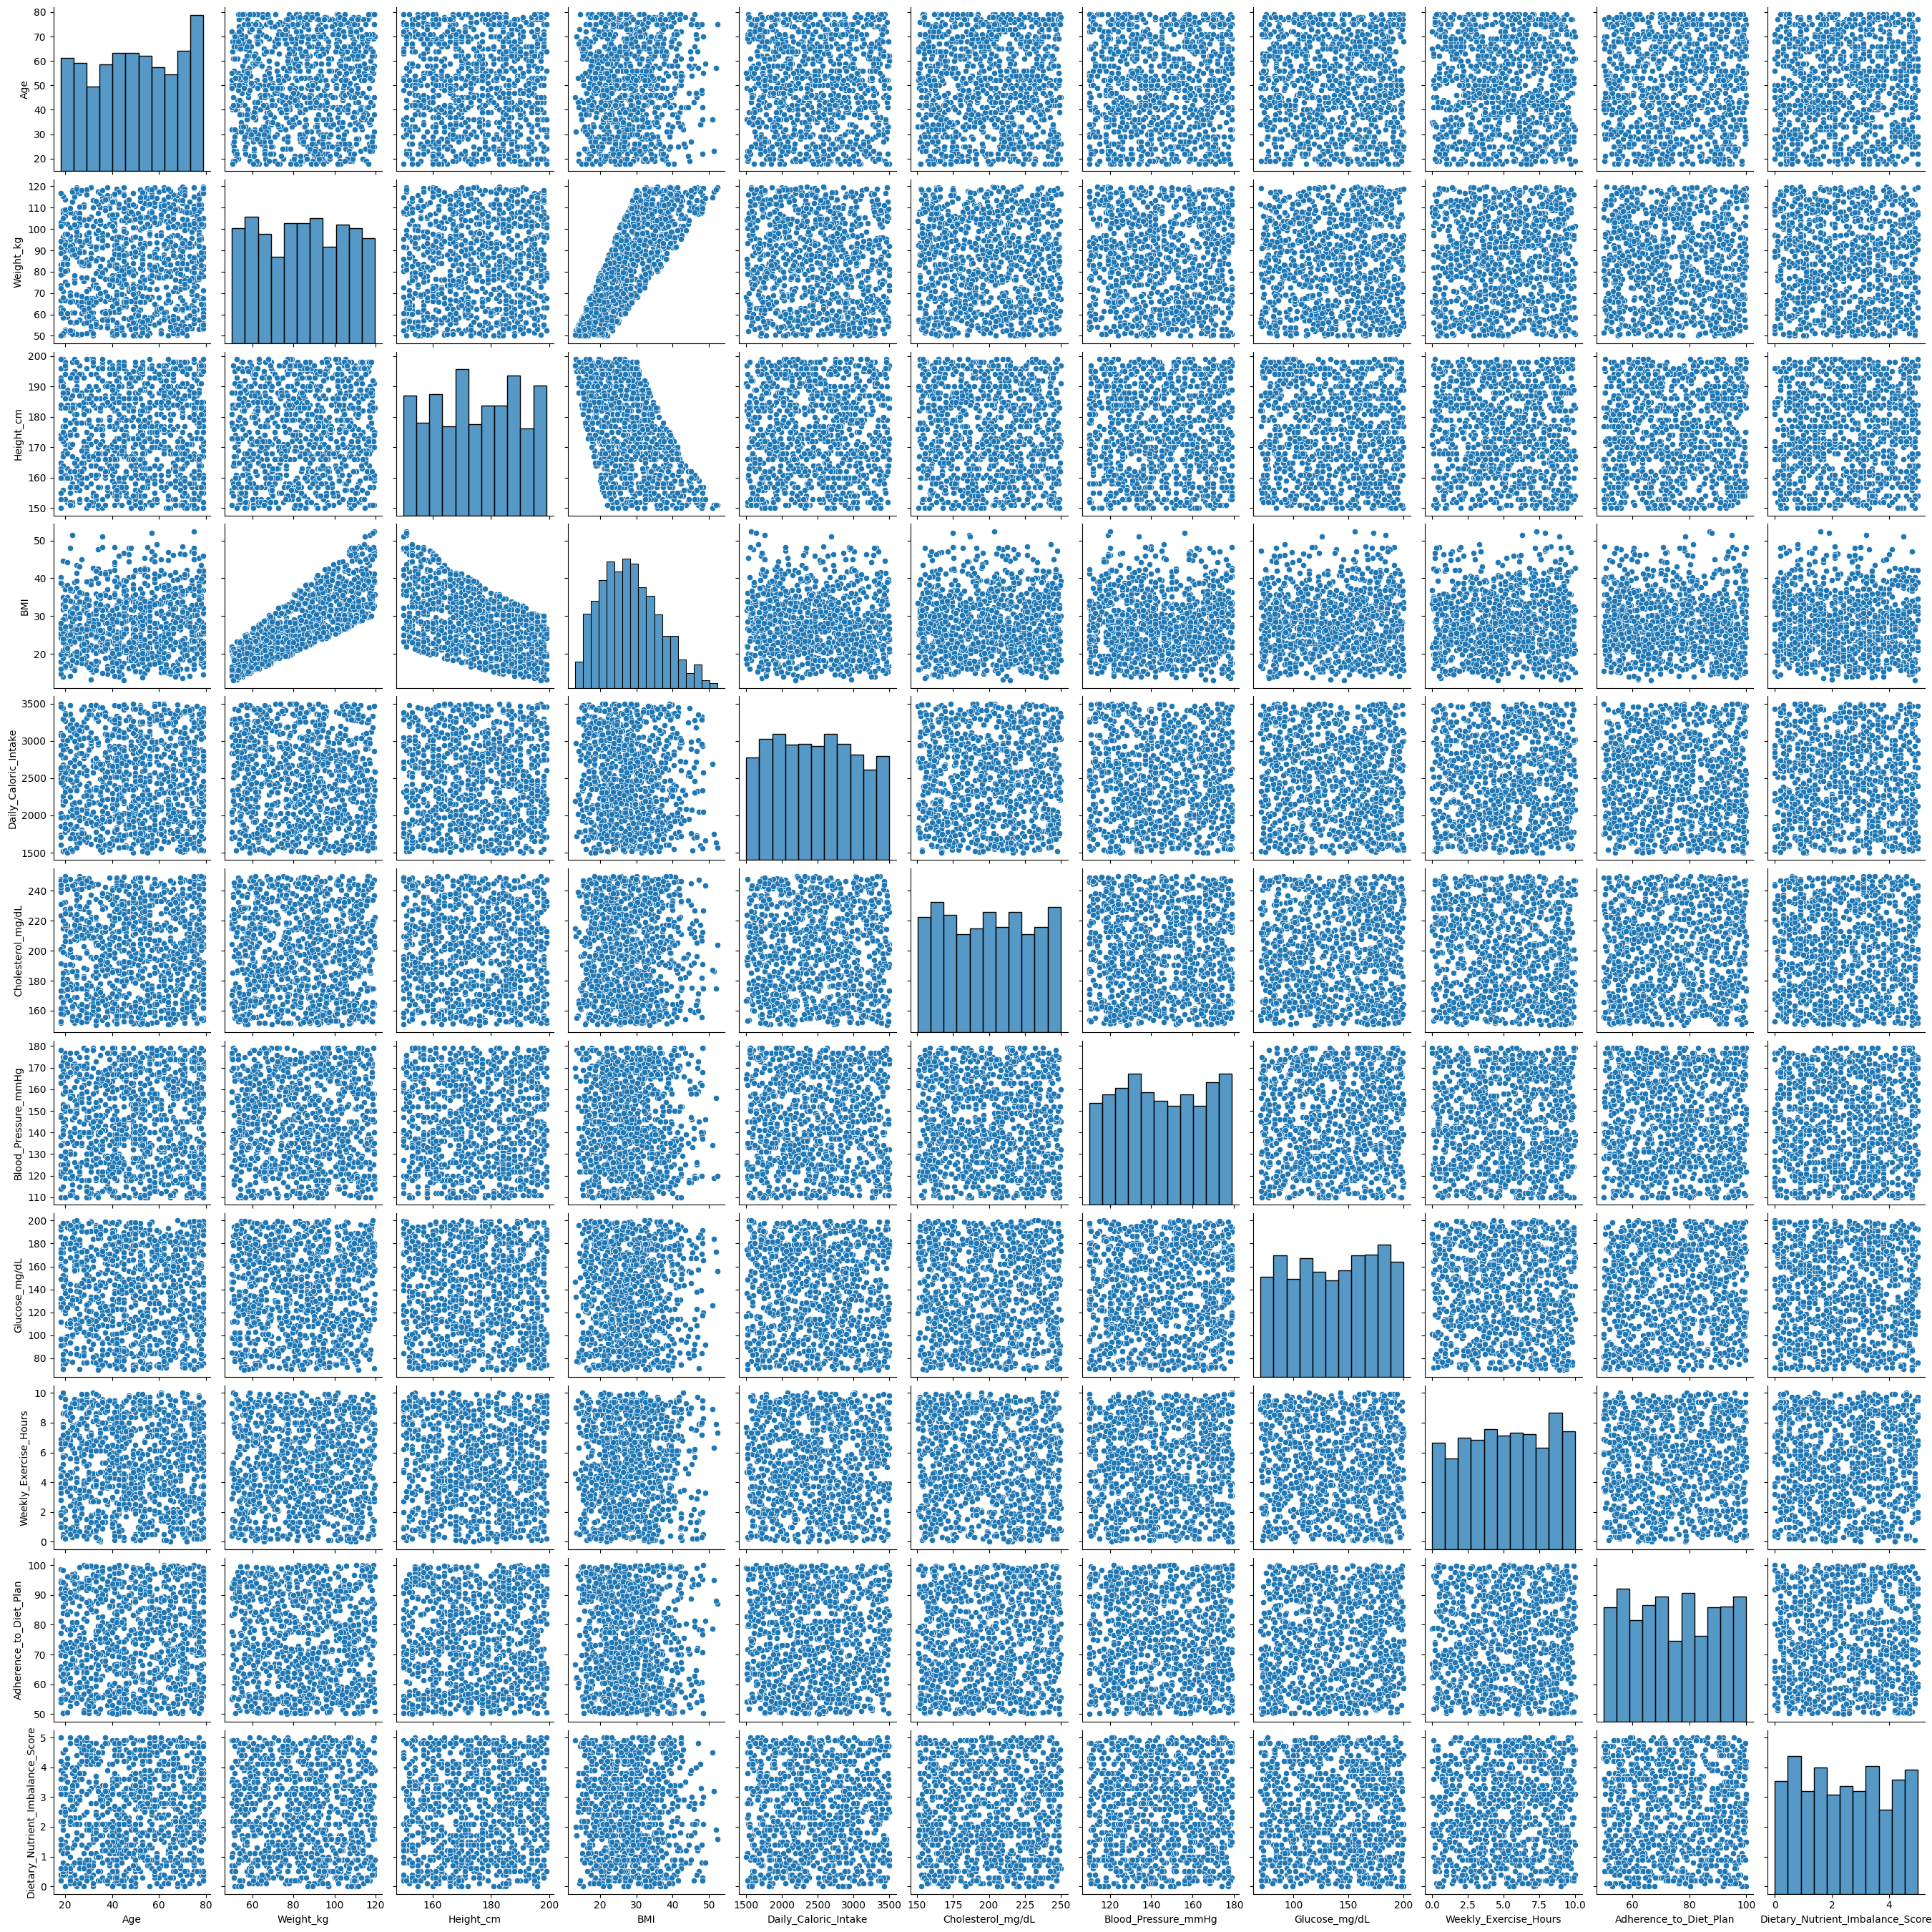

In [18]:
sns.pairplot(df)
plt.show()

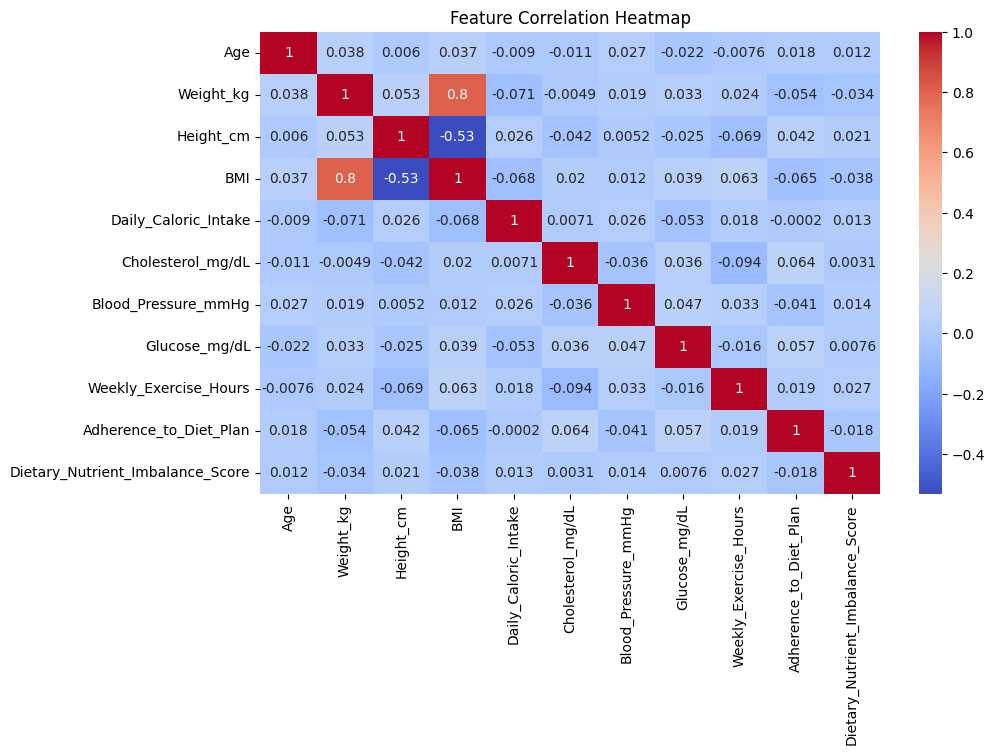

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [20]:
print(df.dtypes)  # Check data types of all columns
print(df.select_dtypes(include=['number']).columns)  # Verify numeric columns

Patient_ID                           object
Age                                   int64
Gender                               object
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                         object
Severity                             object
Physical_Activity_Level              object
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                 object
Allergies                            object
Preferred_Cuisine                    object
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
Diet_Recommendation                  object
dtype: object
Index(['Age', 'Weight_kg', 'Height_cm', 'BMI', 'Daily_Caloric_Intake',
       'Cholesterol_mg/dL', 'Blood_

In [22]:
# Define X and y properly
X = df.drop(columns=["Diet_Recommendation"])  # Features
y = df["Diet_Recommendation"]  # Target

# Convert all features in X to numeric (to avoid errors)
X = X.apply(pd.to_numeric, errors="coerce")

# Debugging: Check if X is correctly defined
print("✅ Feature Columns (X):", X.columns.tolist())  
print("\n✅ Data Types:\n", X.dtypes)  
print("\n✅ Sample Data:\n", X.head())  


✅ Feature Columns (X): ['Patient_ID', 'Age', 'Gender', 'Weight_kg', 'Height_cm', 'BMI', 'Disease_Type', 'Severity', 'Physical_Activity_Level', 'Daily_Caloric_Intake', 'Cholesterol_mg/dL', 'Blood_Pressure_mmHg', 'Glucose_mg/dL', 'Dietary_Restrictions', 'Allergies', 'Preferred_Cuisine', 'Weekly_Exercise_Hours', 'Adherence_to_Diet_Plan', 'Dietary_Nutrient_Imbalance_Score']

✅ Data Types:
 Patient_ID                          float64
Age                                   int64
Gender                              float64
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                        float64
Severity                            float64
Physical_Activity_Level             float64
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                flo

In [23]:
# Drop non-numeric columns (e.g., ID or unnecessary columns)
if "ID" in df.columns:  # Change "ID" to actual column name if different
    df.drop(columns=["ID"], inplace=True)


In [24]:
X = df.drop(columns=["Diet_Recommendation"])  # Drop target column

# Convert all columns in X to numeric (to avoid string errors)
X = X.apply(pd.to_numeric, errors="coerce")

print("Final Data Types After Conversion:\n", X.dtypes)  # Check if conversion worked


Final Data Types After Conversion:
 Patient_ID                          float64
Age                                   int64
Gender                              float64
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                        float64
Severity                            float64
Physical_Activity_Level             float64
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                float64
Allergies                           float64
Preferred_Cuisine                   float64
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
dtype: object


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("diet_recommendations.csv")

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Display first few rows
df.head()


,Patient_ID,Age,Gender,Weight_kg,Height_cm,BMI,Disease_Type,Severity,Physical_Activity_Level,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Dietary_Restrictions,Allergies,Preferred_Cuisine,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score,Diet_Recommendation
0,P0001,56,Male,58.4,160,22.8,Obesity,Moderate,Moderate,3079,173.3,133,116.3,NaN,Peanuts,Mexican,3.1,96.6,3.1,Balanced
1,P0002,69,Male,101.2,169,35.4,Diabetes,Mild,Moderate,3032,199.2,120,137.1,NaN,Peanuts,Chinese,4.5,63.2,0.6,Low_Carb
2,P0003,46,Female,63.5,173,21.2,Hypertension,Mild,Sedentary,1737,181.0,121,109.6,NaN,Peanuts,Chinese,3.8,57.5,4.6,Low_Sodium
3,P0004,32,Male,58.1,164,21.6,NaN,Mild,Moderate,2657,168.2,144,159.4,NaN,NaN,Mexican,4.3,54.5,0.4,Balanced
4,P0005,60,Male,79.5,197,20.5,Diabetes,Moderate,Sedentary,3496,200.4,172,182.3,Low_Sugar,NaN,Italian,9.8,78.2,4.7,Low_Carb


In [26]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Convert numeric columns to float
numeric_columns = ["Age", "Height_cm", "Weight_kg", "BMI"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill missing values in numeric columns with mean
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Check dataset after cleaning
df.info()


Missing Values:
 Patient_ID                            0
Age                                   0
Gender                                0
Weight_kg                             0
Height_cm                             0
BMI                                   0
Disease_Type                        204
Severity                              0
Physical_Activity_Level               0
Daily_Caloric_Intake                  0
Cholesterol_mg/dL                     0
Blood_Pressure_mmHg                   0
Glucose_mg/dL                         0
Dietary_Restrictions                334
Allergies                           323
Preferred_Cuisine                     0
Weekly_Exercise_Hours                 0
Adherence_to_Diet_Plan                0
Dietary_Nutrient_Imbalance_Score      0
Diet_Recommendation                   0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
-

In [27]:
# Basic statistics
df.describe()


,Age,Weight_kg,Height_cm,BMI,Daily_Caloric_Intake,Cholesterol_mg/dL,Blood_Pressure_mmHg,Glucose_mg/dL,Weekly_Exercise_Hours,Adherence_to_Diet_Plan,Dietary_Nutrient_Imbalance_Score
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,49.857000,84.602400,174.81700,28.191600,2475.064000,199.717900,144.993000,136.867600,5.166000,74.88430,2.469200
std,18.114267,20.088121,14.33377,8.040136,565.017032,29.080614,20.245712,37.934819,2.847995,14.82638,1.459631
min,18.000000,50.000000,150.00000,13.000000,1500.000000,150.400000,110.000000,70.200000,0.000000,50.00000,0.000000
25%,35.000000,66.600000,162.00000,22.075000,1984.750000,174.300000,128.000000,105.000000,2.800000,62.00000,1.200000
50%,50.000000,85.200000,175.00000,27.450000,2470.500000,199.850000,145.000000,138.000000,5.200000,74.20000,2.400000
75%,66.000000,102.000000,187.00000,33.425000,2937.250000,224.850000,163.000000,170.650000,7.600000,88.20000,3.700000
max,79.000000,119.700000,199.00000,52.400000,3498.000000,249.900000,179.000000,200.000000,10.000000,100.00000,5.000000


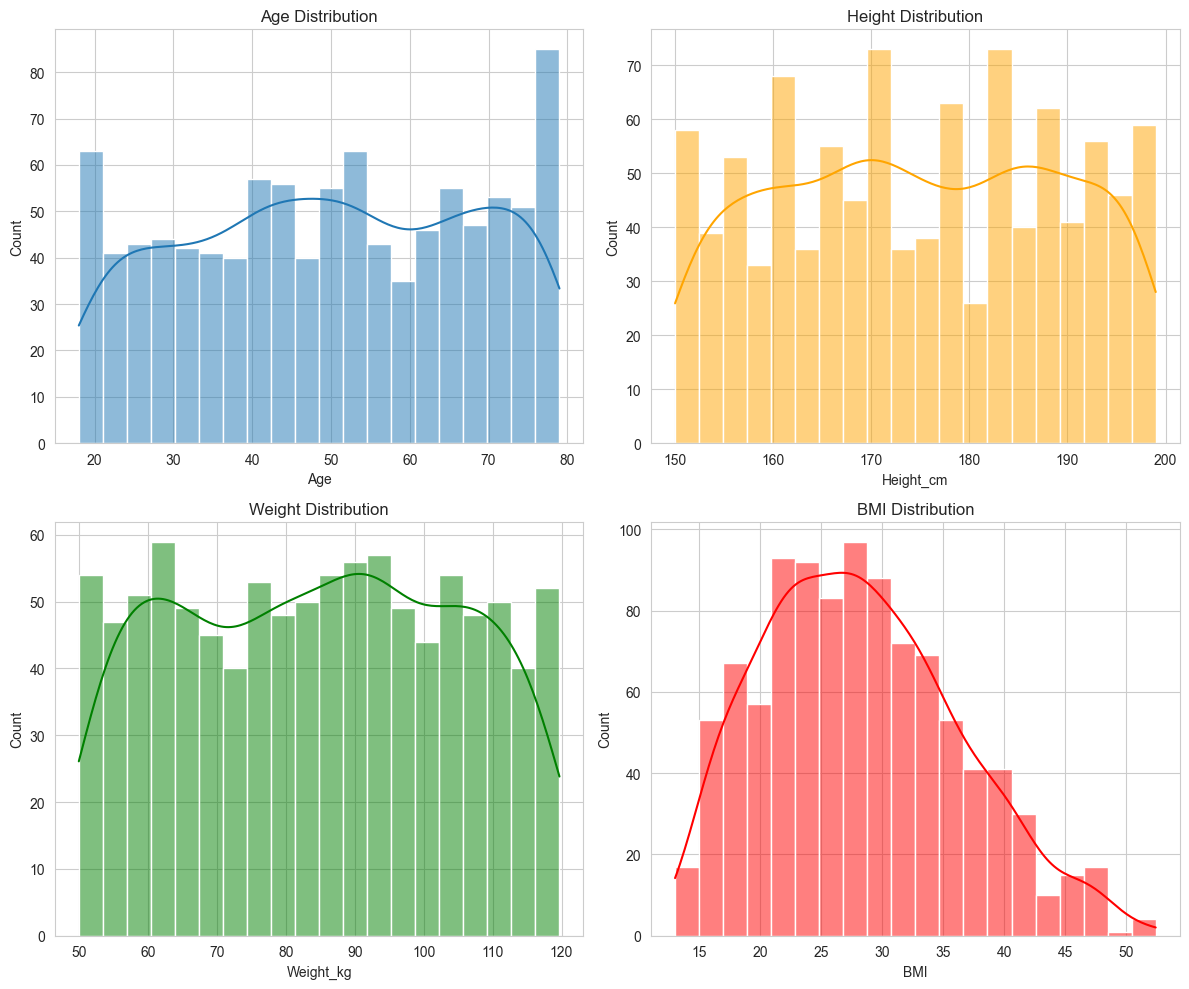

In [28]:
# Set style
sns.set_style("whitegrid")

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution")

sns.histplot(df["Height_cm"], bins=20, kde=True, ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Height Distribution")

sns.histplot(df["Weight_kg"], bins=20, kde=True, ax=axes[1, 0], color="green")
axes[1, 0].set_title("Weight Distribution")

sns.histplot(df["BMI"], bins=20, kde=True, ax=axes[1, 1], color="red")
axes[1, 1].set_title("BMI Distribution")

plt.tight_layout()
plt.show()


In [29]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


ValueError: could not convert string to float: 'P0001'

<Figure size 800x600 with 0 Axes>

In [30]:
print(df.dtypes)


Patient_ID                           object
Age                                   int64
Gender                               object
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                         object
Severity                             object
Physical_Activity_Level              object
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                 object
Allergies                            object
Preferred_Cuisine                    object
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
Diet_Recommendation                  object
dtype: object


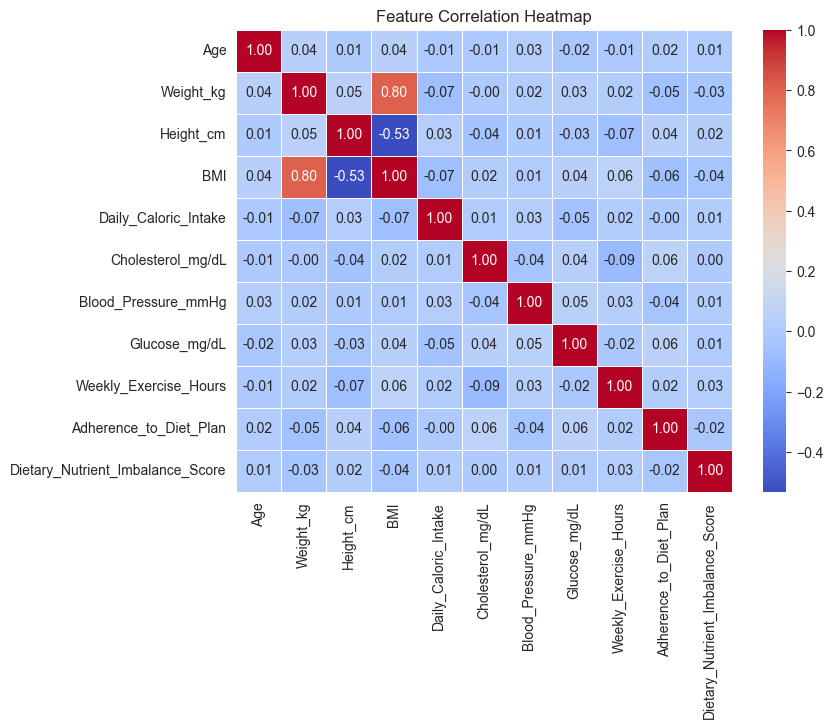

In [31]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [32]:
df.drop(columns=["Patient_ID"], errors="ignore", inplace=True)


In [33]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 800x600 with 0 Axes>

In [34]:
print(df.dtypes)



Age                                   int64
Gender                               object
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                         object
Severity                             object
Physical_Activity_Level              object
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                 object
Allergies                            object
Preferred_Cuisine                    object
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
Diet_Recommendation                  object
dtype: object


In [35]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender (Male → 1, Female → 0)
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

# Save label encoder for later use
import pickle
with open("label_encoder_gender.pkl", "wb") as file:
    pickle.dump(le_gender, file)

print("✅ Gender encoded successfully!")


✅ Gender encoded successfully!


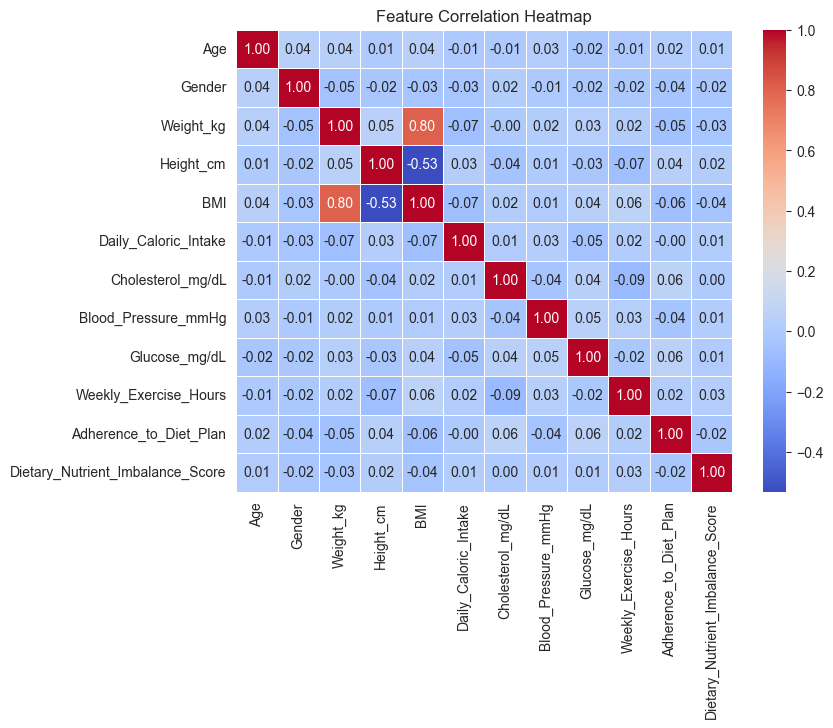

In [37]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


In [38]:
print(df.dtypes)

Age                                   int64
Gender                                int64
Weight_kg                           float64
Height_cm                             int64
BMI                                 float64
Disease_Type                         object
Severity                             object
Physical_Activity_Level              object
Daily_Caloric_Intake                  int64
Cholesterol_mg/dL                   float64
Blood_Pressure_mmHg                   int64
Glucose_mg/dL                       float64
Dietary_Restrictions                 object
Allergies                            object
Preferred_Cuisine                    object
Weekly_Exercise_Hours               float64
Adherence_to_Diet_Plan              float64
Dietary_Nutrient_Imbalance_Score    float64
Diet_Recommendation                  object
dtype: object


C:\Users\Impana\AppData\Local\Temp\ipykernel_23048\2951039568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Gender"], palette="pastel")


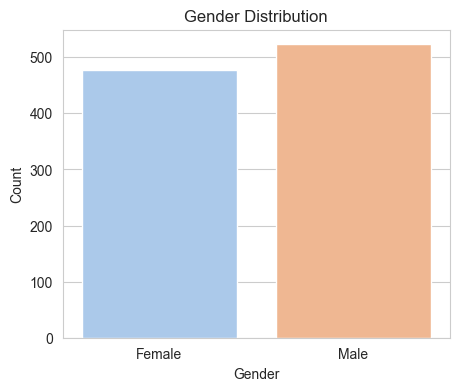

In [40]:
# Countplot for Gender
plt.figure(figsize=(5, 4))
sns.countplot(x=df["Gender"], palette="pastel")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Female", "Male"])
plt.show()


In [41]:
# Check if BMI is correctly calculated
df["Calculated_BMI"] = df["Weight_kg"] / ((df["Height_cm"] / 100) ** 2)

# Compare original vs calculated BMI
df[["BMI", "Calculated_BMI"]].head(10)


,BMI,Calculated_BMI
0,22.8,22.812500
1,35.4,35.432933
2,21.2,21.216880
3,21.6,21.601725
4,20.5,20.484939
5,43.4,43.433596
6,35.4,35.363322
7,14.7,14.747403
8,26.7,26.742857
9,23.2,23.248946


In [42]:
from sklearn.preprocessing import LabelEncoder

# Encode Gender: Female = 0, Male = 1
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

# Save label encoder for later use
import pickle
with open("label_encoder_gender.pkl", "wb") as file:
    pickle.dump(le_gender, file)

# Save cleaned dataset
df.to_csv("cleaned_diet_data.csv", index=False)
print("✅ Data cleaned and saved as 'cleaned_diet_data.csv'")


✅ Data cleaned and saved as 'cleaned_diet_data.csv'


In [43]:
print("✅ Encoded Gender Classes:", le_gender.classes_)  


✅ Encoded Gender Classes: [0 1]
